__Markus Mulvihill__

__Last updated April 2026__

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

In [2]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

 

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

In [3]:
try:
    SI_ests = np.load(
        "../scripts/saved_variables/module4/SI_ests_integral_static_04.npy"
    )
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_integral_static_04.npy"
    )
    SI_errs_int_static = SI_errs.copy()
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_integral_static_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral.py")

Loaded variables


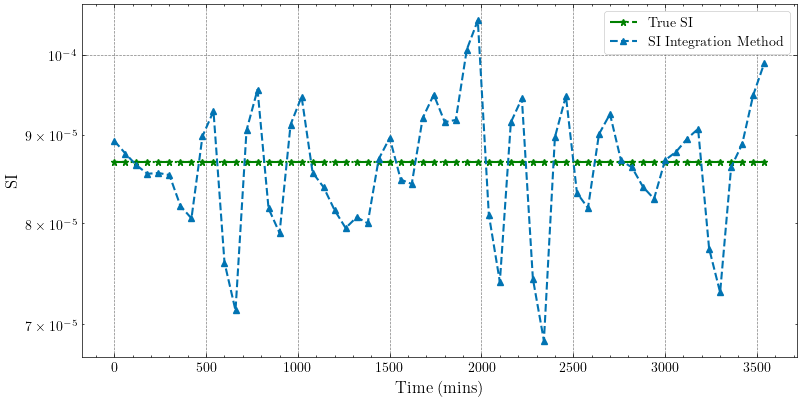

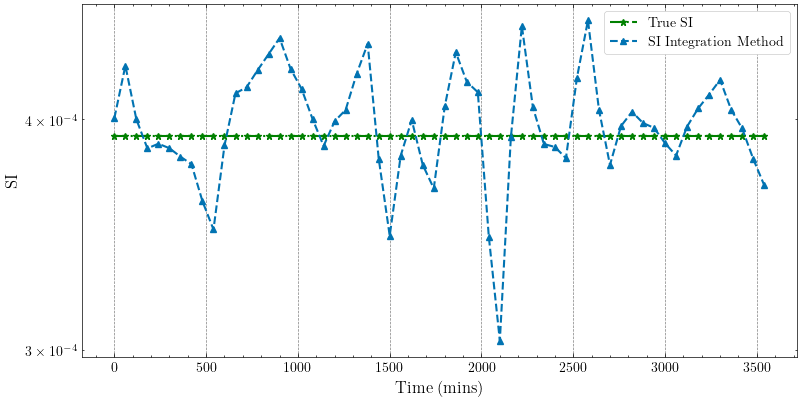

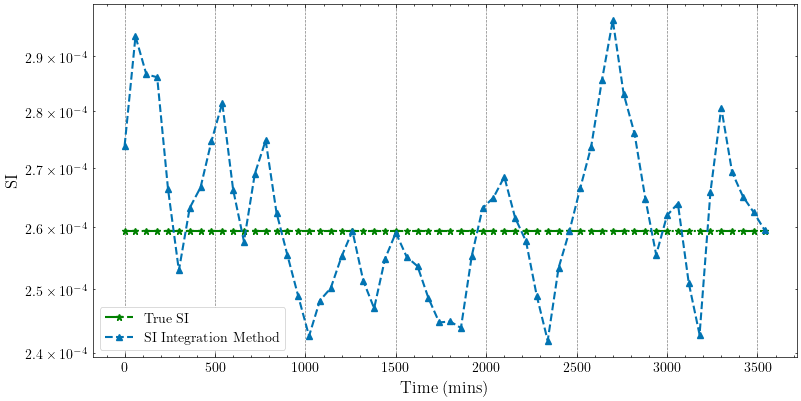

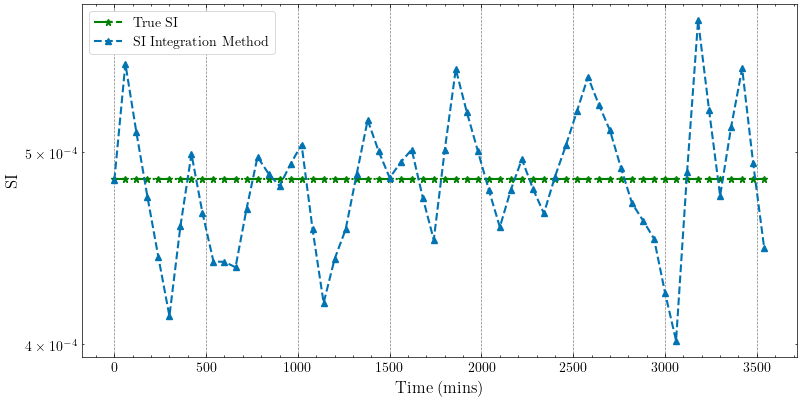

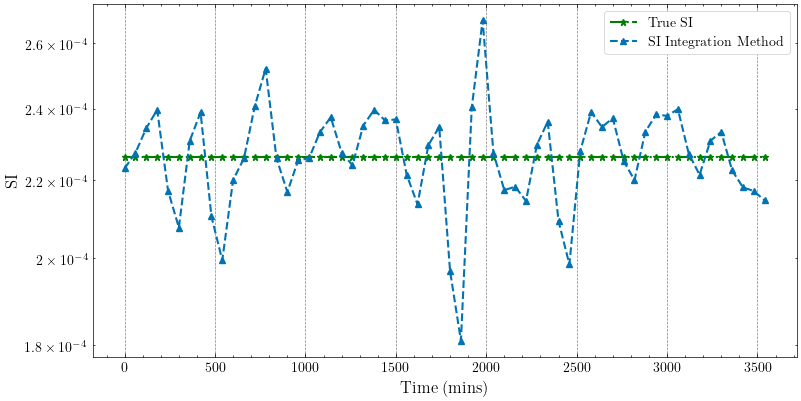

In [4]:
time = np.arange(SI_true_arr.shape[1]) * 60
palette = sns.color_palette("colorblind", 1)

for i in range(5):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(
        time, true_SI, linestyle="-.", marker="*", color="green", label="True SI"
    )
    est = SI_ests[i, :]
    ax.semilogy(
        time,
        est,
        linestyle="--",
        marker="^",
        color=palette[0],
        label="SI Integration Method",
    )
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

In [5]:
total_mard = np.average(SI_errs, axis=(0, 1))
print("Total MARD: ", total_mard)

Total MARD:  0.06194378626474953


In [6]:
try:
    SI_ests = np.load("../scripts/saved_variables/module4/SI_ests_integral_vary_04.npy")
    SI_errs = np.load("../scripts/saved_variables/module4/SI_errs_integral_vary_04.npy")
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_integral_vary_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral_vary.py")

Loaded variables


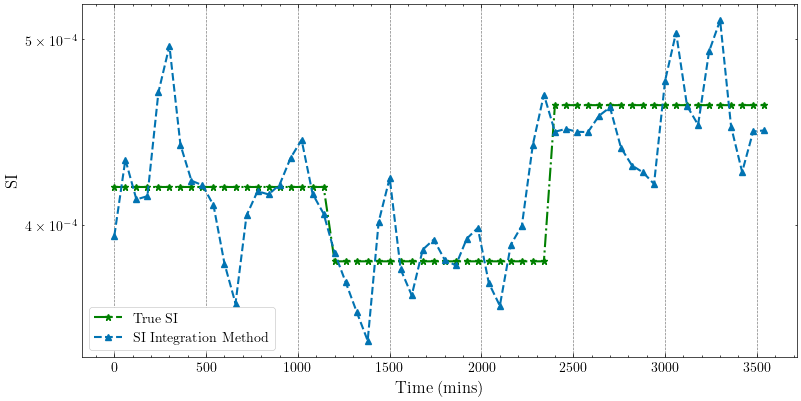

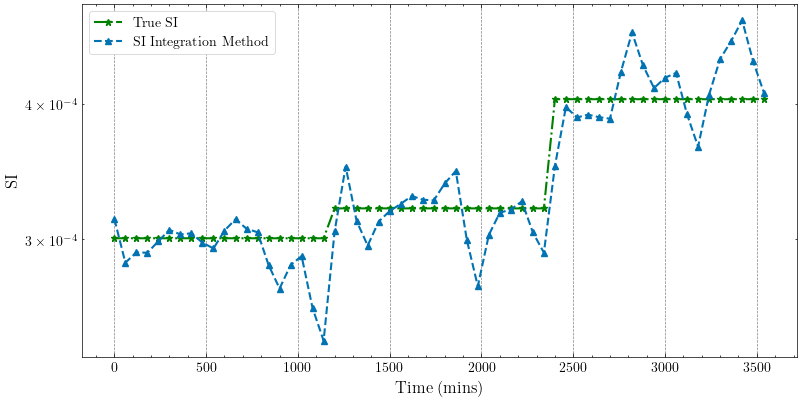

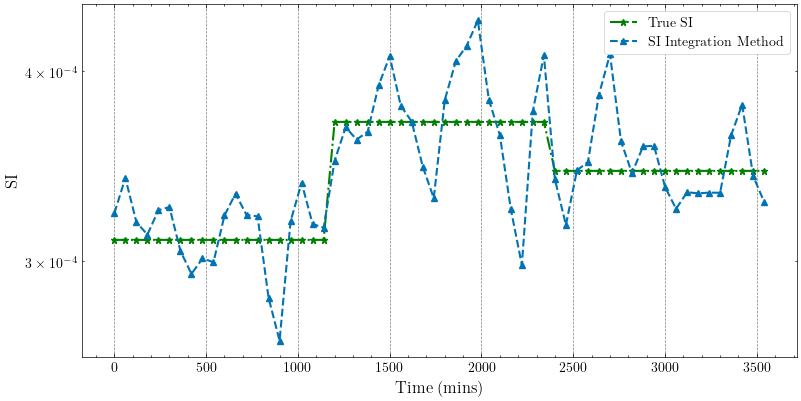

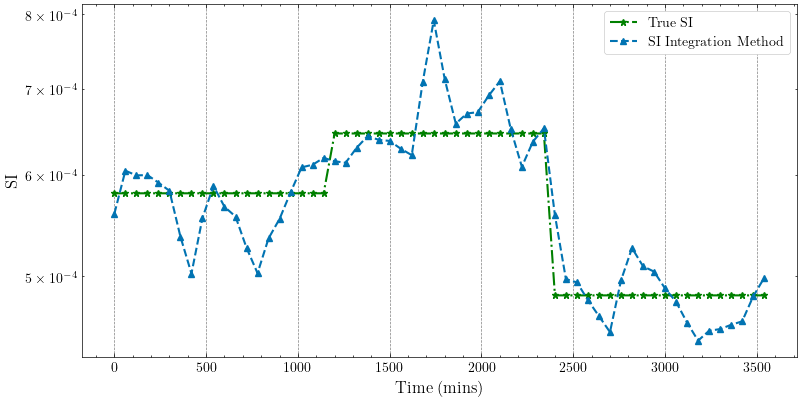

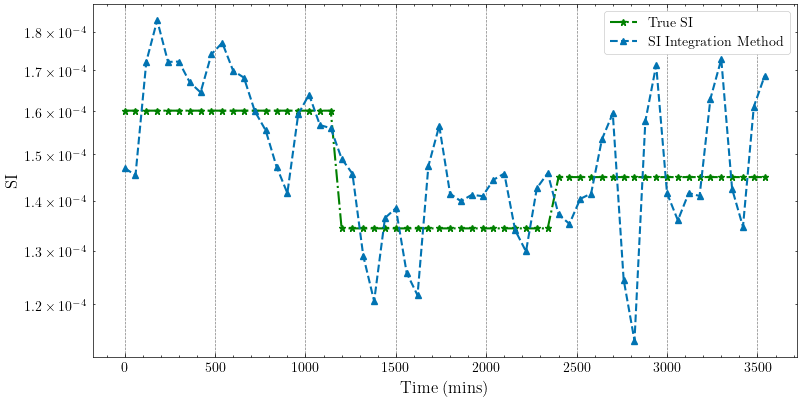

In [7]:
for i in range(5):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(
        time, true_SI, linestyle="-.", marker="*", color="green", label="True SI"
    )
    est = SI_ests[i, :]
    ax.semilogy(
        time,
        est,
        linestyle="--",
        marker="^",
        color=palette[0],
        label="SI Integration Method",
    )
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

In [8]:
total_mard = np.average(SI_errs, axis=(0, 1))
print("Total MARD: ", total_mard)

Total MARD:  0.06261896011105487


In [9]:
try:
    SI_ests = np.load(
        "../scripts/saved_variables/module4/SI_ests_augment_static_04.npy"
    )
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_augment_static_04.npy"
    )
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_augment_static_04.npy"
    )
    # G_true_arr = np.load("../scripts/saved_variables/module4/G_true_arr_augment_static_04.npy")
    # states = np.load("../scripts/saved_variables/module4/states_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


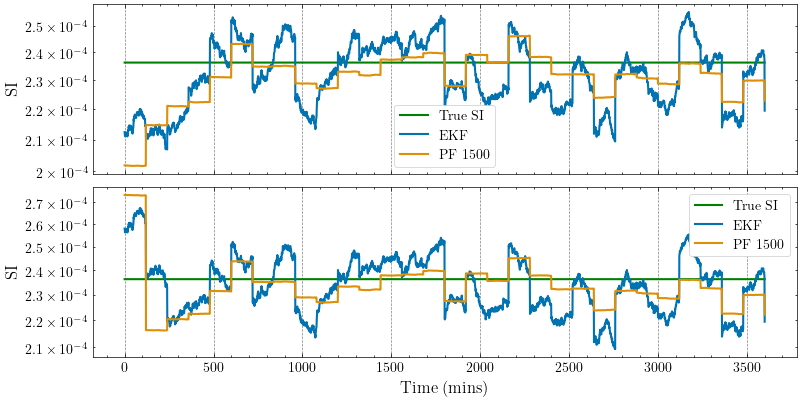

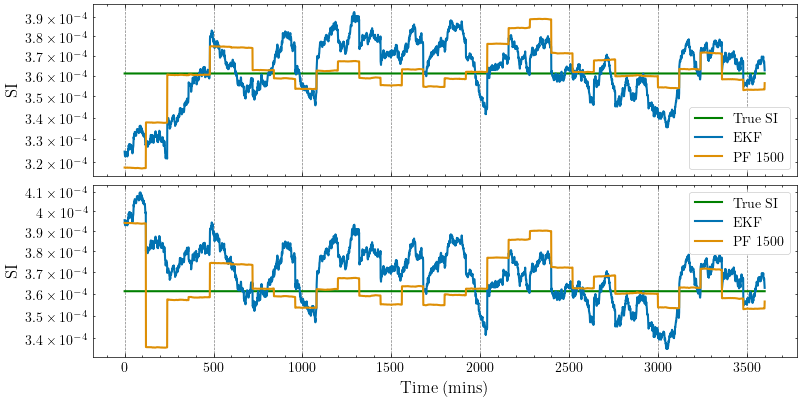

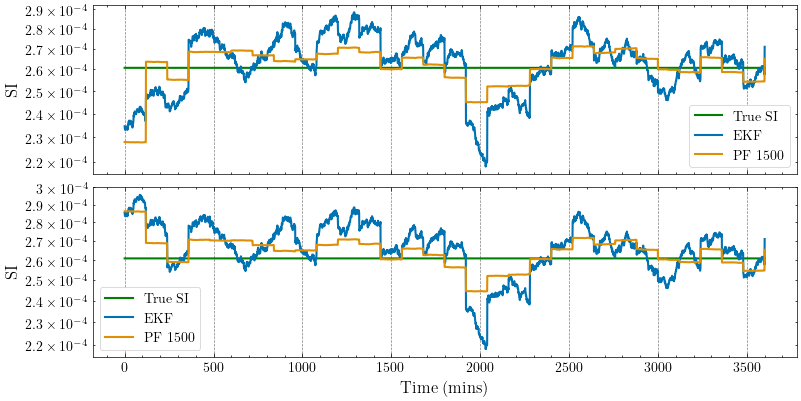

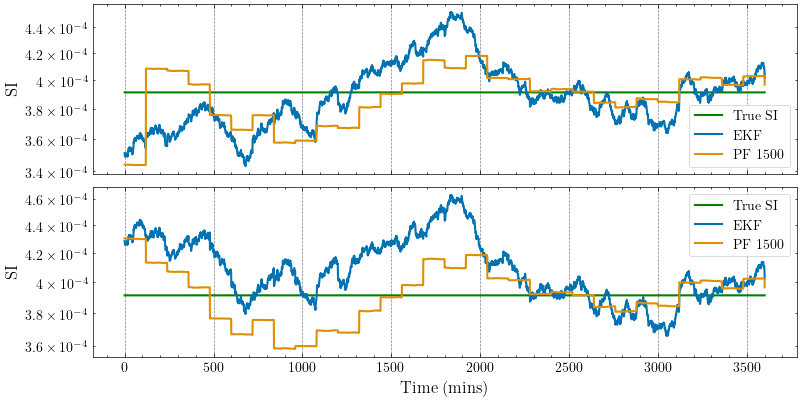

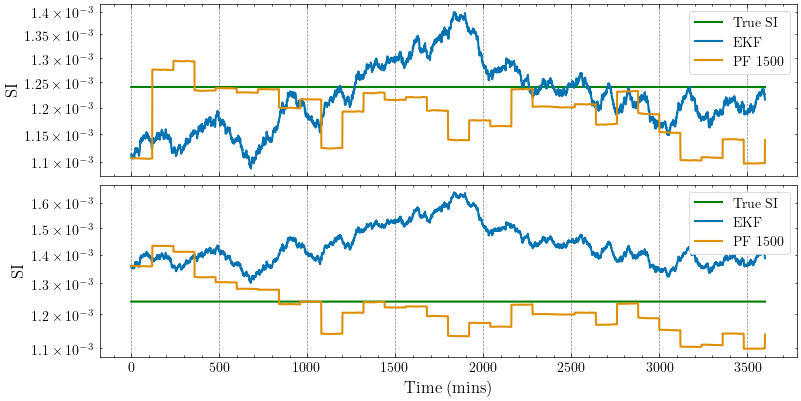

In [10]:
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters + 1)

for i in range(5):
    fig, ax = plt.subplots(num_deviations, 1, figsize=(8, 4), sharex=True)
    for j in range(num_deviations):
        true_SI = SI_true_arr[i, :]
        ax[j].semilogy(time, true_SI, color="green", label="True SI")
        for k in range(num_filters):
            patient = i
            est = SI_ests[j, k, i, :]
            ax[j].semilogy(
                time, est, linestyle="-", color=palette[k], label=f"{filters[k]}"
            )
            ax[j].set_ylabel("SI")
            ax[j].legend()

    ax[j].set_xlabel("Time (mins)")

In [11]:
total_mard = np.average(SI_errs, axis=(0, 2, 3))
print("Total MARD: ", total_mard / 100)

Total MARD:  [0.06291432 0.03370003]


# SI piecewise 

In [13]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    # SI_ests_2500 = np.load("../scripts/variables/SI_ests_augment_vary_new_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    # SI_errs_2500 = np.load("../scripts/variables/SI_errs_augment_vary_new_04.npy")
    SI_true_arr = np.load(
        "../scripts/variables/SI_true_arr_augment_vary_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


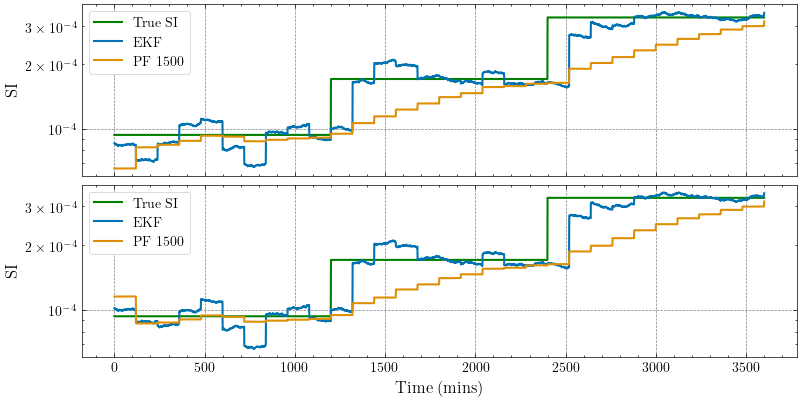

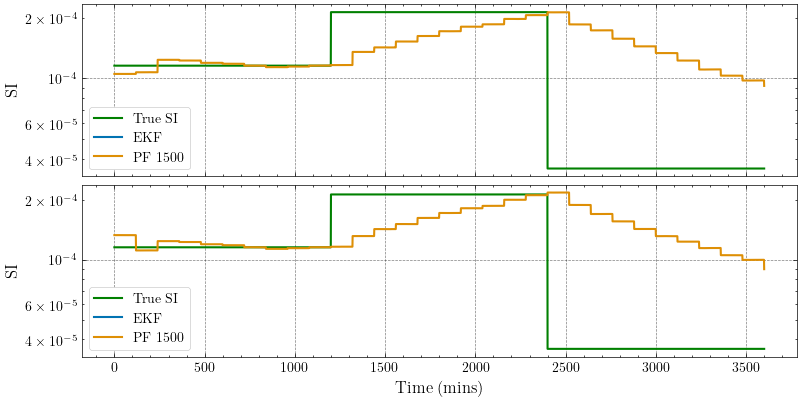

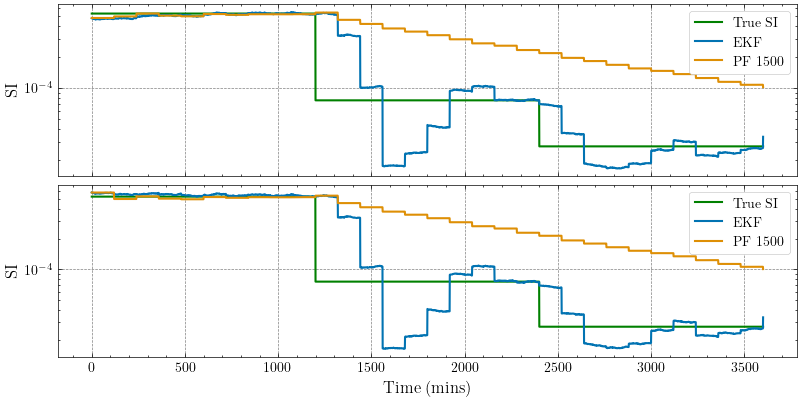

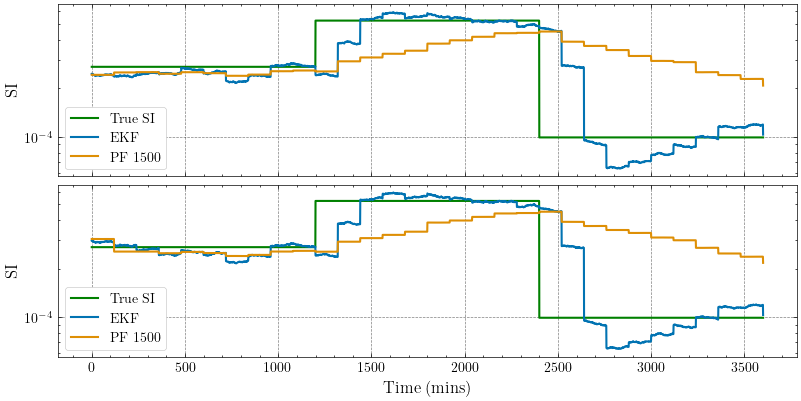

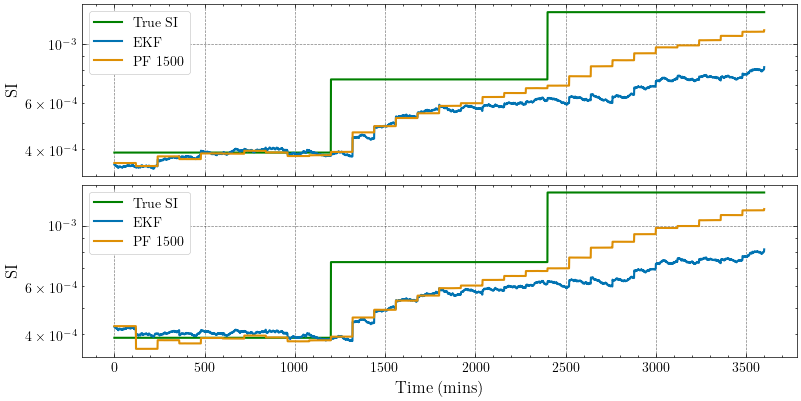

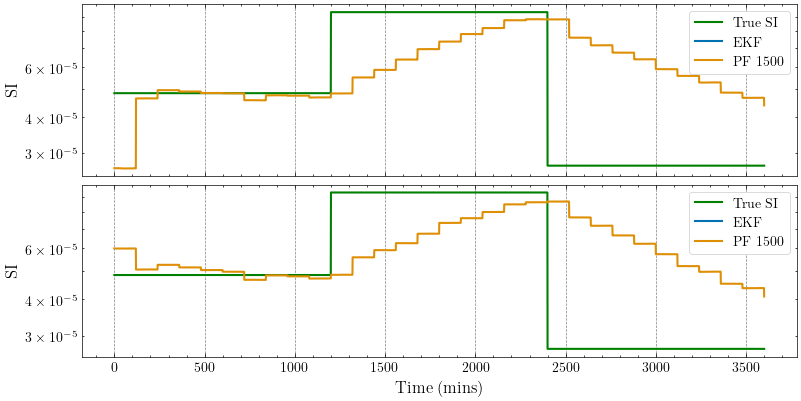

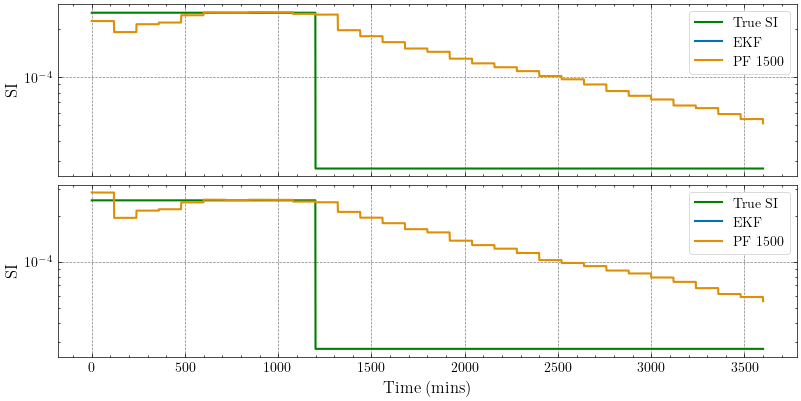

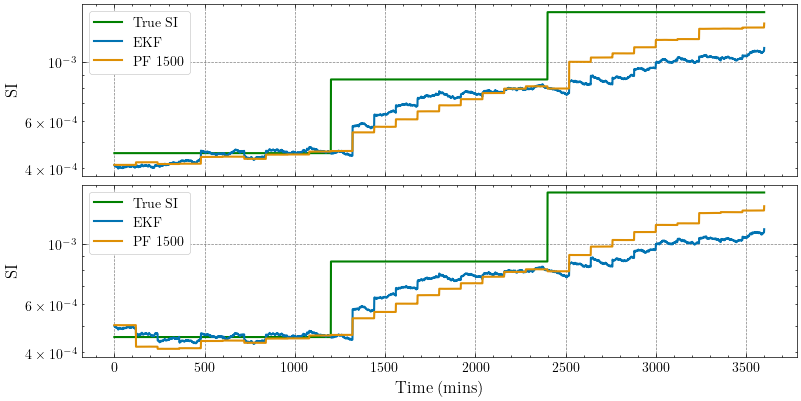

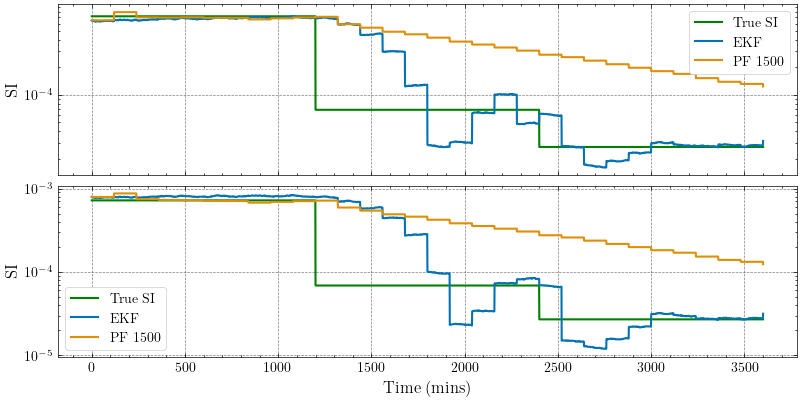

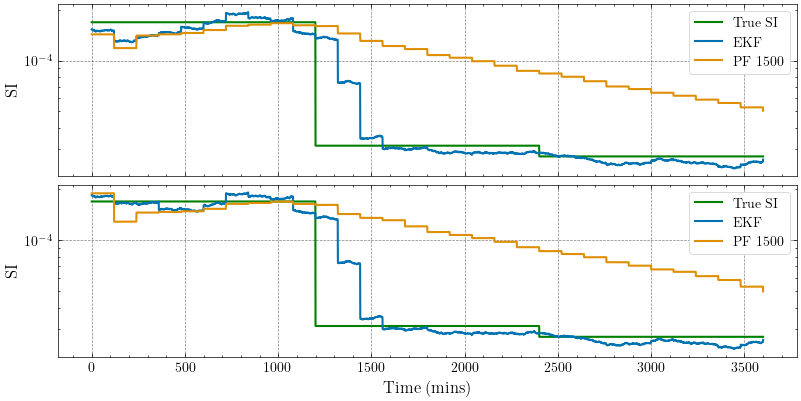

In [15]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

for i in range(10):
    fig, ax = plt.subplots(num_deviations, 1, figsize=(8, 4), sharex=True)
    for j in range(num_deviations):
        true_SI = SI_true_arr[i, :]
        m_true = np.isfinite(true_SI)
        ax[j].semilogy(time[m_true], true_SI[m_true], color="green", label="True SI")

        for k in range(num_filters):
            est = SI_ests[j, k, i, :]
            m = np.isfinite(est)
            ax[j].semilogy(time[m], est[m], linestyle="-", color=palette[k], label=f"{filters[k]}")

        ax[j].set_ylabel("SI")
        ax[j].legend()
    ax[-1].set_xlabel("Time (mins)")


In [20]:
total_mard = np.nanmedian(SI_errs, axis=(0, 2, 3))
print("Total MARD: ", total_mard / 100)
invalid_runs = (~np.isfinite(SI_ests[:,0,:,:]).all(axis=(-1))).sum()
print("ekf failure rate: ", invalid_runs / (100*num_deviations))

Total MARD:  [0.12831697        nan]
ekf failure rate:  0.25


In [ ]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    # mean_err_2500 = np.mean(SI_errs_2500[j, :, :, :], axis=1)
    time = np.arange(mean_err.shape[1])
    mean_err_int = np.mean(SI_errs_int_static, axis=0)
    time_int = 60 * np.arange(mean_err_int.shape[0])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters + 1)

    fig, ax = plt.subplots(figsize=(5.1, 3.75))

    for i in range(num_plots):
        ax.plot(
            time,
            abs(mean_err[i]) / 100,
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"{filters[i]}",
        )
    # ax.plot(
    #     time,
    #     mean_err_2500[1] / 100,
    #     color=palette[2],
    #     linewidth=1.2,
    #     alpha=0.95,
    #     linestyle=["-", "--", "-.", ":"][2],
    #     label="PF 2500",
    # )
    # ax.plot(
    #     time_int,
    #     abs(mean_err_int),
    #     color=palette[2],
    #     linewidth=1.2,
    #     alpha=0.95,
    #     linestyle=["-", "--", "-.", ":"][2],
    #     label="Integral-based Method",
    # )
    x = 1800
    plt.axvline(x=x, color="red", linewidth=1.2, alpha=0.95, linestyle=":")
    ymin, ymax = plt.ylim()
    ypos = ymin + 0.95 * (ymax - ymin)  # adjust vertical offset as needed
    plt.text(x + 5, ypos, r"$\,S_I$ change", color="red", va="bottom", ha="right")
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("MARD")
    ax.legend(loc="best")
    fig.savefig("figures/5_5.pdf", format="pdf")


In [ ]:
total_mard = abs(np.average(SI_errs / 100, axis=(2, 3)))
print("Total MARD: ", total_mard)
print(np.average(mean_err_int))